In [2]:
import struct
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

**Objective and goal for this lab**

For this lab, we're going to see how we can transform images to a format we're used to working with, and can thus use for training classification (or regression) models.

We will be using the MNIST-dataset, which is a famous dataset of handwritten black & white digits between 0-9. Our goal will be to train a classifier to correctly classify each image as the digit it portrays.

You can read more about MNIST [here](https://en.wikipedia.org/wiki/MNIST_database).

---

**Load the data**

In [3]:
import struct

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        return np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        return np.fromfile(f, dtype=np.uint8)

# Load training data
train_images = load_mnist_images("../data/mnist/train-images.idx3-ubyte")
train_labels = load_mnist_labels("../data/mnist/train-labels.idx1-ubyte")

# Load test data
test_images = load_mnist_images("../data/mnist/t10k-images.idx3-ubyte")
test_labels = load_mnist_labels("../data/mnist/t10k-labels.idx1-ubyte")

Let's investigate what we just loaded

In [4]:
print('train_images shape :', train_images.shape)
print('test_images shape  :', test_images.shape, end='\n\n')

print('train_labels shape :', train_labels.shape)
print('test_labels shape  :', test_labels.shape)

train_images shape : (60000, 28, 28)
test_images shape  : (10000, 28, 28)

train_labels shape : (60000,)
test_labels shape  : (10000,)


So both train and test images are 3D-arrays. Let's pick the first item in train_images and investigate it

In [5]:
print('train_images[0] :', train_images[0].shape)

train_images[0] : (28, 28)


So, the first (out of 60.000) items in train_images is a 28x28 array. Actually, it's an image of size 28x28 pixels.

We can visualise this easily

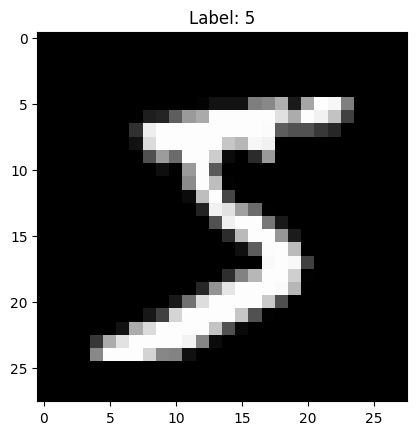

In [6]:
plt.imshow(train_images[0], cmap='gray');
plt.title(f'Label: {train_labels[0]}')
plt.show()

As you might've noticed, the train_labels contain the true labels (i.e., the targets) for each handwritten image.

Let's plot some more images

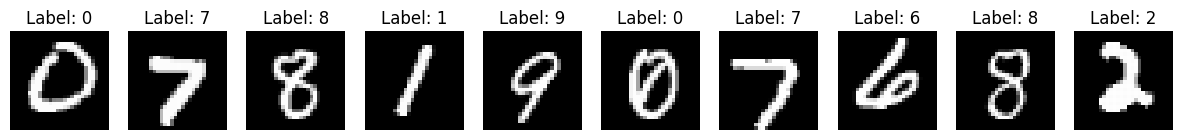

In [7]:
import random

number_of_images = 10

indices = random.sample(range(60000), number_of_images)

fig, axes = plt.subplots(1, number_of_images, figsize=(15, 3))

for idx, ax in zip(indices, axes):
    ax.imshow(train_images[idx], cmap='gray')
    ax.set_title(f'Label: {train_labels[idx]}')
    ax.axis('off')

plt.show()

In [8]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

---

Ok, so how do we transform this data into a format that we can train the models we've learnt about thus far? 

Well,  what we'll do is that we're going to use *every pixel as it's own feature*. Since each image is 28x28 pixels, we're going to have 28x28 = 784 features for each image.

We can use flatten() to transform a 2D (28,28) shaped array to a single 1D (784) array.

In [9]:
# easy transformation

train_images[0].flatten().shape

(784,)

In [10]:
# now we do it for all the images in the train_images

train_images_flattened = [list(image.flatten()) for image in train_images]

In [11]:
train_images_flattened_array = np.array([image.flatten() for image in train_images])

# transform that list to a dataframe so that we can see what's going on
X_train_val = pd.DataFrame(train_images_flattened_array)

X_train_val


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
X_train_val.describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [13]:
# might aswell make the labels into a dataframe too

y_train_val = pd.DataFrame(train_labels)

y_train_val

,0
0,5
1,0
2,4
3,1
4,9
...,...
59995,8
59996,3
59997,5
59998,6


In [14]:
y_train_val.value_counts()

0
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

Cool, no we're on familiar ground! We have our X_train_val (features) and y_train_val (targets) in a suitable format.

Now we can try training some multiclass classification models on this data!

---

## Challenges

**Task 1**

Transform test_images and test_labels similarly as above, and save them as X_test and y_test.

This is the test set you will use at the end, to assess final performance!

In [15]:
# now we do it for all the images in the test_images

test_images_flattened = [list(image.flatten()) for image in test_images]

test_images_flattened_array = np.array([image.flatten() for image in test_images])

# transform that list to a dataframe so that we can see what's going on
X_test = pd.DataFrame(test_images_flattened_array)

X_test

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
y_test = pd.DataFrame(test_labels)

y_test

,0
0,7
1,2
2,1
3,0
4,4
...,...
9995,2
9996,3
9997,4
9998,5


**Task 1.5 (bonus**)

Let's normalize our features! Because why not. It won't hurt the algorithms that don't require it - and we might aswell show how easily images can be scaled properly.

In the case for gray-scale images, we simply divide all features (pixels) by 255. Why? Because that's the maximum possible value. This will bring all grayscale values to the range [0,1].

In [17]:
X_train_val = X_train_val/255

X_test = X_test/255

In [18]:
X_train_val.describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000786,0.000348,0.000179,0.000076,0.000059,0.000008,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023696,0.015514,0.011137,0.006615,0.006582,0.001359,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.996078,0.996078,0.992157,0.992157,0.996078,0.243137,0.0,0.0,0.0,0.0


Awesome. Done. Feel free to check that all grayscale values are properly scaled.

**Task 2**

Using all 784 features (no additional feature engineering or manipulation needed), start GridSearching for the best performing hyperparameters for 

KNN, DecisionTree, RandomForest, AdaBoost 

**Task 3**

When you have the best performing hyperparameters, do an ordinary train/validation split on X_train_val and y_train_val.

Train the models with their respective best performing hyperparameters on X_train and then evaluate performance on X_val.

In particular, make good use of confusion matrices here.

**Task 4**

For the models you've trained in Task 3, try plotting the validation samples they classified **incorrectly**. As the title for each image, write the true label and the predicted label.

Do the mistakes kinda make sense? Can you forgive your models? :)

**Task 5**

For each model with the identified best performing hyperparameters, do a full training on X_train_val - then assess performance on X_test.

Which model did you find to perform worst/best? Is the difference large?

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

### *We're going to pretend that the default hyperparameters are best here...*

Train and predict with KNN

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train_val, y_train_val)

c:\Users\Leyla\miniconda3\envs\databehandling\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
knn_pred = knn.predict(X_test)

In [22]:
knn_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [23]:
knn_pred_probabilities = knn.predict_proba(X_test)

Train and predict with RF

In [24]:
rf = RandomForestClassifier()
rf.fit(X_train_val, y_train_val)

c:\Users\Leyla\miniconda3\envs\databehandling\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
rf_pred = rf.predict(X_test)

In [26]:
rf_pred_probabilities = rf.predict_proba(X_test)

Evaluate KNN

In [27]:
y_test.value_counts()

0
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64

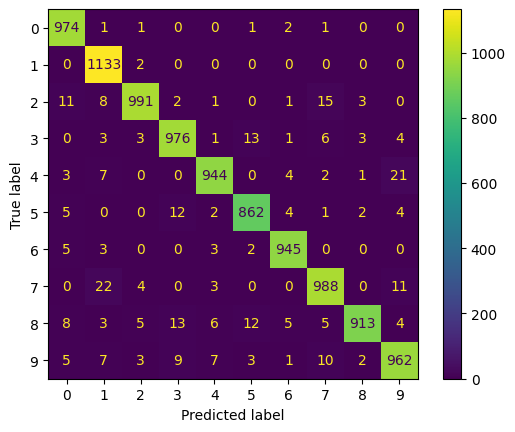

In [28]:
cm = confusion_matrix(y_true=y_test, y_pred=knn_pred.reshape(-1,1))

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

cm_display.plot()
plt.show() 

In [29]:
accuracy = accuracy_score(y_test, knn_pred)
print("Accuracy:", accuracy, end='\n\n')

report = classification_report(y_test, knn_pred)
print("Classification Report:\n", report)

Accuracy: 0.9688

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.95      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Evaluate RF

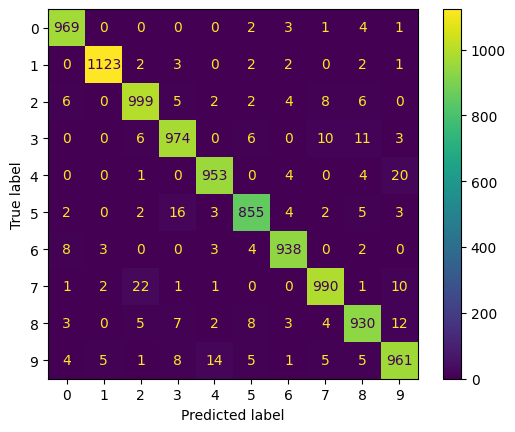

In [30]:
cm = confusion_matrix(y_true=y_test, y_pred=rf_pred.reshape(-1,1))

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

cm_display.plot()
plt.show() 

In [31]:
accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", accuracy, end='\n\n')

report = classification_report(y_test, rf_pred)
print("Classification Report:\n", report)

Accuracy: 0.9692

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Let's plot missclassifcations made by the RF, for some error analysis

In [32]:
misclassified_indices = np.where(rf_pred != y_test.values.ravel())[0]

misclassified_indices

array([ 125,  241,  247,  259,  320,  321,  340,  381,  403,  445,  447,
        448,  449,  543,  551,  578,  582,  628,  646,  659,  684,  707,
        717,  720,  740,  810,  839,  844,  881,  900,  924,  926,  938,
        947,  950,  951,  959,  965, 1014, 1062, 1107, 1112, 1114, 1173,
       1181, 1182, 1192, 1200, 1202, 1226, 1232, 1242, 1247, 1260, 1283,
       1299, 1319, 1325, 1326, 1328, 1337, 1393, 1469, 1476, 1494, 1500,
       1522, 1527, 1530, 1549, 1553, 1559, 1609, 1641, 1681, 1709, 1717,
       1732, 1737, 1754, 1782, 1790, 1813, 1850, 1901, 1941, 1955, 1982,
       2016, 2024, 2035, 2043, 2044, 2053, 2070, 2098, 2099, 2109, 2118,
       2129, 2130, 2135, 2182, 2185, 2186, 2189, 2224, 2266, 2272, 2293,
       2299, 2369, 2381, 2387, 2406, 2422, 2447, 2462, 2488, 2526, 2534,
       2573, 2578, 2597, 2598, 2607, 2648, 2654, 2713, 2770, 2771, 2780,
       2853, 2863, 2896, 2927, 2939, 2953, 2995, 2998, 3005, 3060, 3073,
       3117, 3146, 3160, 3206, 3289, 3330, 3333, 33

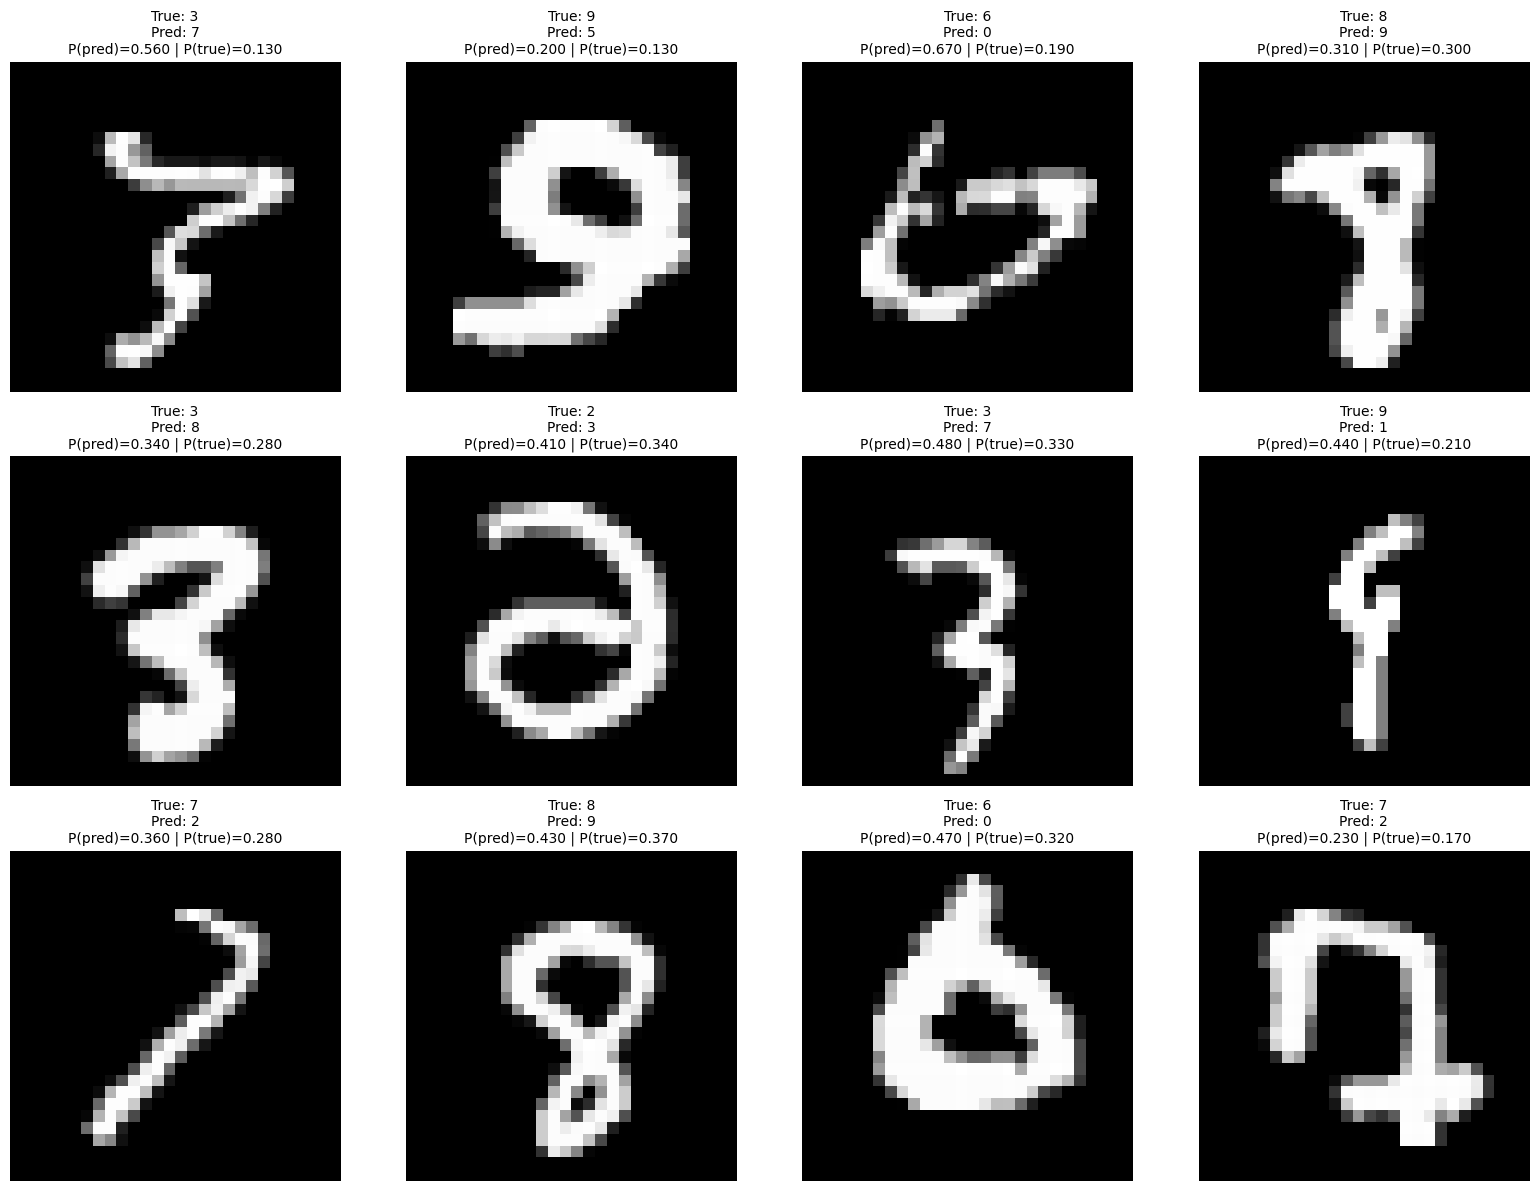

In [33]:
np.random.shuffle(misclassified_indices)

num_images_to_display = 12

def plot_misclassified_grid(images, y_true, y_pred, y_pred_proba, misclassified_indices, class_names=None, n_cols=4):
    selected_indices = misclassified_indices[:num_images_to_display]
    n_images = len(selected_indices)
    n_rows = int(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected_indices):
        predicted_class = y_pred[idx]
        correct_class = y_true[idx]

        predicted_label = class_names[predicted_class] if class_names is not None else predicted_class
        correct_label = class_names[correct_class] if class_names is not None else correct_class

        predicted_class_probability = y_pred_proba[idx][predicted_class]
        correct_class_probability = y_pred_proba[idx][correct_class]

        ax.imshow(images[idx], cmap='gray')
        ax.set_title(
            f"True: {correct_label}\nPred: {predicted_label}\n"
            f"P(pred)={predicted_class_probability:.3f} | P(true)={correct_class_probability:.3f}",
            fontsize=10
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_misclassified_grid(
    images=test_images,
    y_true=y_test.values.ravel(),
    y_pred=rf_pred,
    y_pred_proba=rf_pred_probabilities,
    misclassified_indices=misclassified_indices
)


**Task 6**

If you feel frisky, you can try a tad more difficult problem. Try loading and training on the [Fashion MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist) dataset instead. 

It's a relatively more difficult dataset to classify.

### Fashion-MNIST solution with RandomForest

Below we solve the final challenge using a `RandomForestClassifier`, then do the same kind of error analysis as above.

In [34]:
from sklearn.datasets import fetch_openml

fashion_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fashion_mnist_data = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X_fashion_full = fashion_mnist_data.data.reshape(-1, 28, 28).astype(np.uint8)
y_fashion_full = fashion_mnist_data.target.astype(np.uint8)

fashion_train_images = X_fashion_full[:60000]
fashion_train_labels = y_fashion_full[:60000]
fashion_test_images = X_fashion_full[60000:]
fashion_test_labels = y_fashion_full[60000:]

print('fashion_train_images shape:', fashion_train_images.shape)
print('fashion_test_images shape :', fashion_test_images.shape)

fashion_train_images shape: (60000, 28, 28)
fashion_test_images shape : (10000, 28, 28)


In [35]:
X_fashion_train = pd.DataFrame([image.flatten() for image in fashion_train_images]) / 255
X_fashion_test = pd.DataFrame([image.flatten() for image in fashion_test_images]) / 255

y_fashion_train = fashion_train_labels
y_fashion_test = fashion_test_labels

X_fashion_train.shape, X_fashion_test.shape

((60000, 784), (10000, 784))

In [36]:
fashion_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

fashion_rf.fit(X_fashion_train, y_fashion_train)

fashion_rf_pred = fashion_rf.predict(X_fashion_test)
fashion_rf_pred_probabilities = fashion_rf.predict_proba(X_fashion_test)

In [37]:
fashion_accuracy = accuracy_score(y_fashion_test, fashion_rf_pred)
print(f"Fashion-MNIST RandomForest accuracy: {fashion_accuracy:.4f}\n")

print(classification_report(
    y_fashion_test,
    fashion_rf_pred,
    target_names=fashion_class_names
))

Fashion-MNIST RandomForest accuracy: 0.8778

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.77      0.80      0.79      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.77      0.83      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.71      0.59      0.64      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



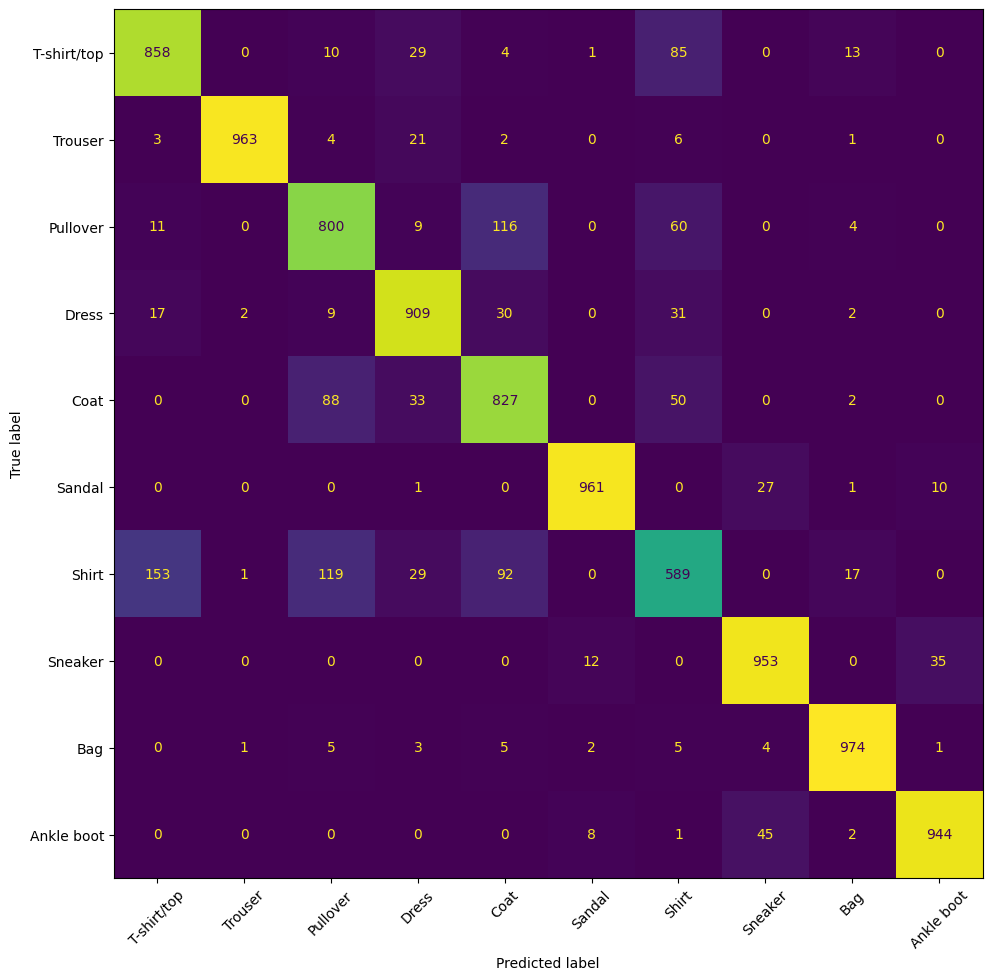

In [38]:
fashion_cm = confusion_matrix(y_true=y_fashion_test, y_pred=fashion_rf_pred)

fashion_cm_display = ConfusionMatrixDisplay(
    confusion_matrix=fashion_cm,
    display_labels=fashion_class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
fashion_cm_display.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

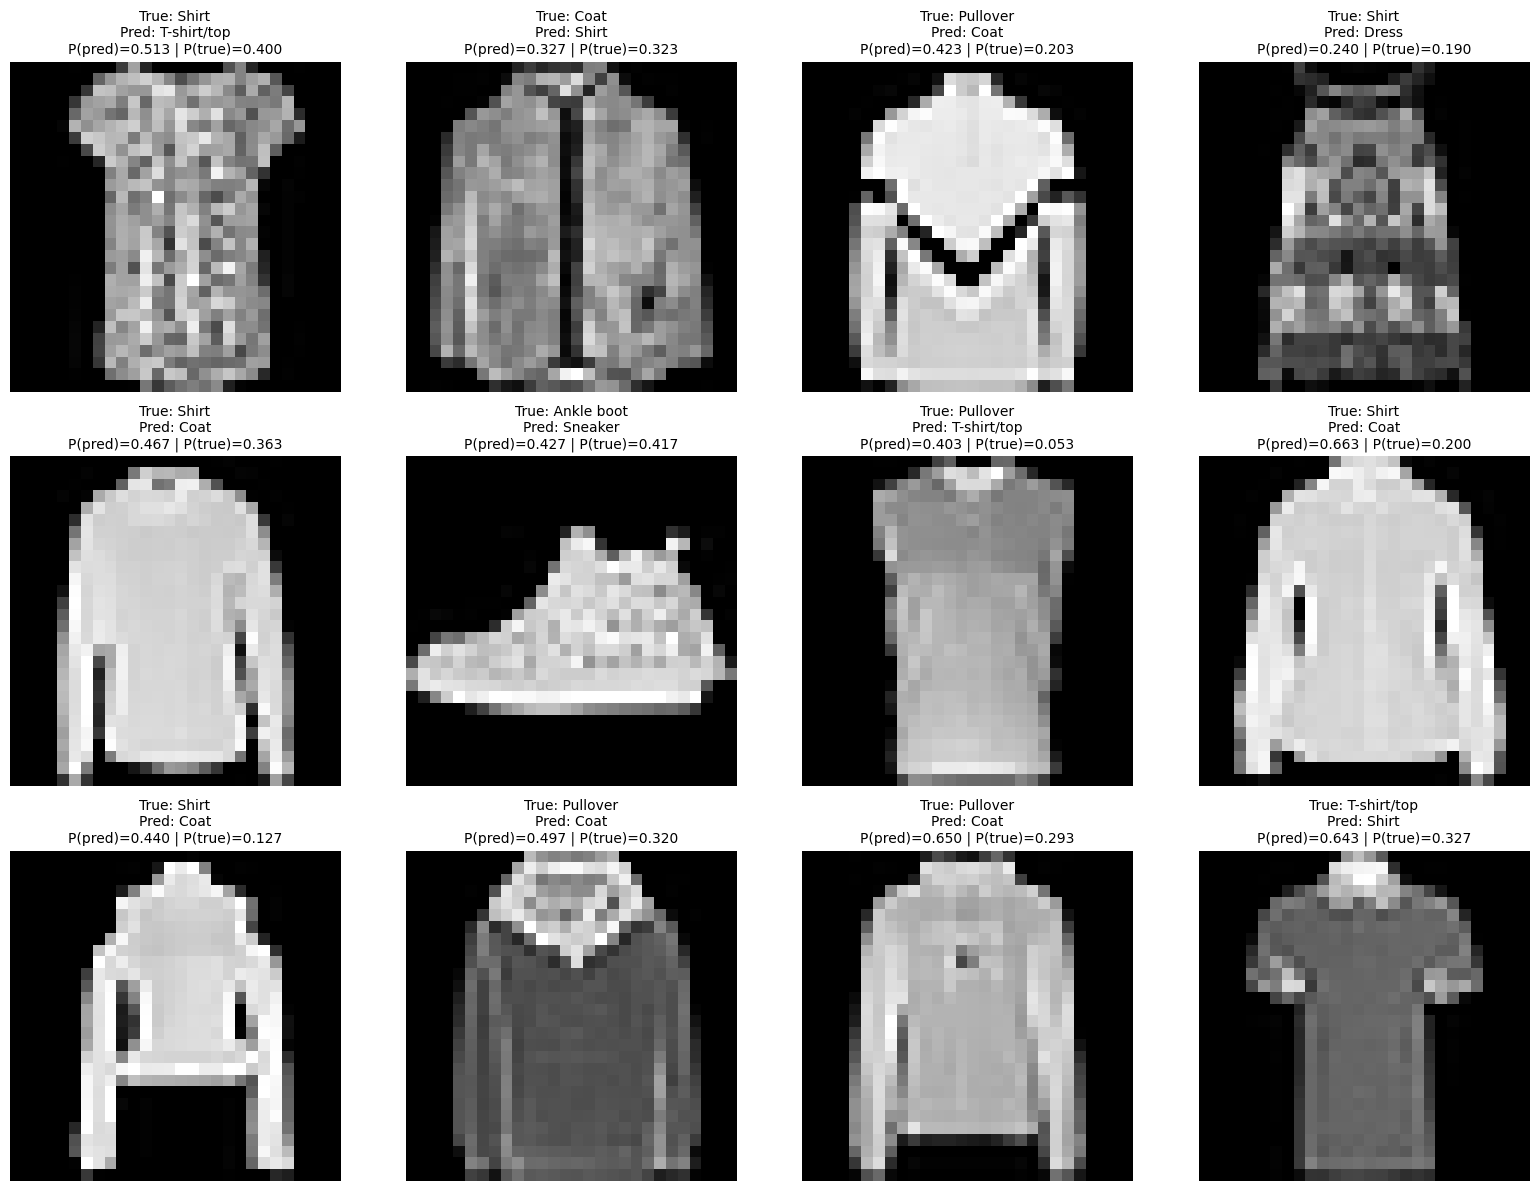

In [39]:
fashion_misclassified_indices = np.where(fashion_rf_pred != y_fashion_test)[0]
np.random.shuffle(fashion_misclassified_indices)

plot_misclassified_grid(
    images=fashion_test_images,
    y_true=y_fashion_test,
    y_pred=fashion_rf_pred,
    y_pred_proba=fashion_rf_pred_probabilities,
    misclassified_indices=fashion_misclassified_indices,
    class_names=fashion_class_names
)